# Task 3: RL portfolio allocation

Equal-weight baseline, PPO and DDPG on `PortfolioOptimizationEnv`.
Scaled features, the 25-asset tuning split, trial logs and episode metrics live in `RLUtils`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stockstats import wrap
from stable_baselines3 import A2C, PPO, DDPG

from utils import Utils
from RLUtils import RLUtils

plt.rcParams["font.family"] = "DejaVu Sans"


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Data


In [2]:
features = wrap(pd.read_csv("./data/features_panel.csv")).reset_index()

TRAIN_WINDOW = 1000  # sessions
TEST_WINDOW = 400    # sessions
train, test = Utils.train_test_split(features, TRAIN_WINDOW, TEST_WINDOW)
train = train.dropna().reset_index(drop=True)
test = test.reset_index(drop=True)
recent = RLUtils.last_n_sessions(features, 500)

FEATURE_LIST = RLUtils.FEATURE_LIST
# ppo_portfolio.zip and ddpg_portfolio.zip were trained before macdh_stad joined RLUtils.FEATURE_LIST,
# so the loaded models read these 10 columns. A fresh search (TRAIN_* = True) uses FEATURE_LIST.
SAVED_FEATURE_LIST = [f for f in FEATURE_LIST if f != "macdh_stad"]
tune_train = RLUtils.subset_assets(train, RLUtils.TUNE_N_ASSETS)
print(
    f"tuning on {tune_train['tic'].nunique()} of {train['tic'].nunique()} assets, "
    f"{tune_train['date'].nunique()} sessions"
)

# True runs the Optuna searches (slow). False loads ppo_portfolio.zip / ddpg_portfolio.zip.
TRAIN_PPO = False
TRAIN_DDPG = False

tuning on 25 of 100 assets, 1000 sessions


Check one observation for its shape, scale and NaNs before training.


In [3]:
RLUtils.describe_observation(train, FEATURE_LIST)


Dict('last_action': Box(0.0, 1.0, (101,), float32), 'state': Box(-inf, inf, (11, 100, 1), float32))
state (11, 100, 1) float32
features ['boll_pctb', 'volume_stad', 'rsi_6_scale', 'macd_stad', 'macds_stad', 'macdh_stad', 'adx_scale', 'pvo_stad', 'tema_stad', 'stochrsi_3_scale', 'log-ret_stad']
date 2016-02-08 00:00:00
                  count      mean       std       min       25%       50%  \
boll_pctb         100.0  0.298411  0.319344 -0.133875  0.018599  0.210178   
volume_stad       100.0  0.634905  0.857512 -0.942026  0.010370  0.553605   
rsi_6_scale       100.0  0.397119  0.219301  0.090091  0.212952  0.337643   
macd_stad         100.0 -0.905407  1.450856 -2.755324 -2.135118 -1.484011   
macds_stad        100.0 -0.432230  1.531547 -2.691451 -1.933571 -0.561479   
macdh_stad        100.0 -1.171096  1.295238 -2.735774 -2.161043 -1.741673   
adx_scale         100.0  0.302082  0.309493  0.000000  0.000000  0.238757   
pvo_stad          100.0  0.020609  0.038741 -0.068966 -0.004018 

,boll_pctb,volume_stad,rsi_6_scale,macd_stad,macds_stad,macdh_stad,adx_scale,pvo_stad,tema_stad,stochrsi_3_scale,log-ret_stad
Asset_001,0.415361,-0.211488,0.444478,-0.269742,-0.527820,0.127515,0.000000,-0.048088,-0.281336,0.490342,0.502340
Asset_002,0.091994,0.355718,0.244890,-2.063852,-1.502880,-1.976863,0.118569,0.026493,-1.701649,0.000000,-0.386099
Asset_003,0.153107,0.036153,0.276823,-1.930710,-1.037393,-1.915284,0.027792,0.064212,-1.575086,0.000000,0.103584
Asset_004,0.085081,0.330687,0.173201,-1.849206,-2.009123,-1.656773,0.468940,0.023780,-1.619654,0.000000,-0.178742
Asset_005,-0.083138,1.841125,0.139737,-2.458195,-2.565141,-2.382074,0.280754,0.086242,-2.322370,0.000000,-1.095539
...,...,...,...,...,...,...,...,...,...,...,...
Asset_096,0.656890,-0.402916,0.701708,0.915178,1.251955,-0.641727,0.625366,-0.029667,0.599421,0.000000,-0.701771
Asset_097,0.208285,0.107097,0.368576,-0.091191,1.300704,-1.302362,0.064627,-0.014227,-0.630209,0.000000,-1.448877
Asset_098,0.623678,-0.285174,0.604616,0.578571,1.061970,-0.502621,0.094211,-0.023984,0.395671,0.000000,-0.329294
Asset_099,-0.126887,2.389548,0.117093,-2.522898,-1.620244,-2.545735,0.981663,0.039380,-2.427567,0.000000,-1.794524


## Equal-weight portfolio

Baseline: 1/n in every asset, no cash, rebalanced every session.


Initial portfolio value:10000
Final portfolio value: 24284.31640625
Final accumulative portfolio value: 2.428431749343872
Maximum DrawDown: -0.183092889432525
Sharpe ratio: 1.7891503625891279
Mean ex-ante daily vol: 0.007337164772193811
Mean deviation from equal weight: 1.1288758490701095e-08


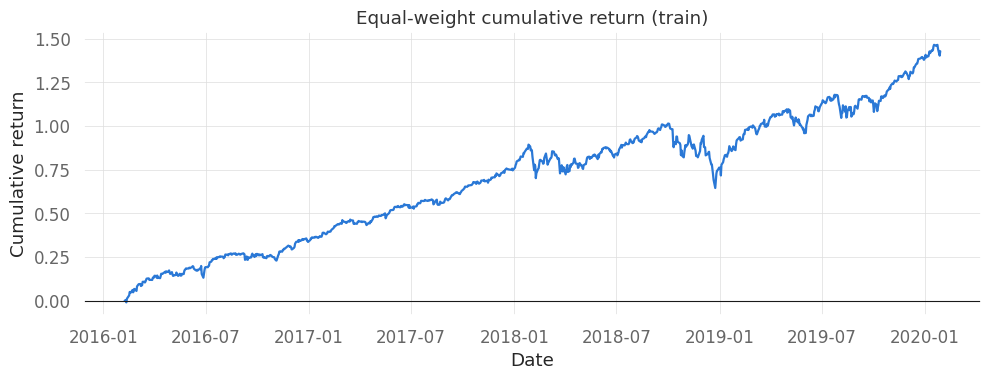

Initial portfolio value:10000
Final portfolio value: 14778.77734375
Final accumulative portfolio value: 1.4778777360916138
Maximum DrawDown: -0.3344595556386084
Sharpe ratio: 0.9946216000037386
Mean ex-ante daily vol: 0.013834896965586903
Mean deviation from equal weight: 1.1288758490701097e-08


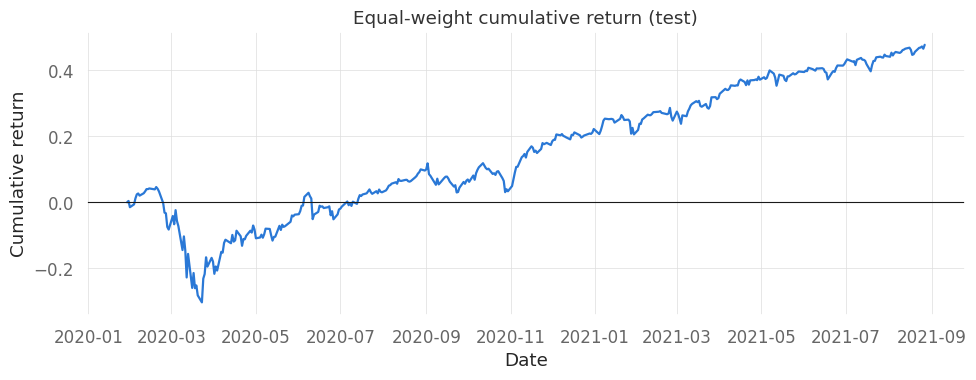

In [4]:
for name, df in {"train": train, "test": test}.items():
    RLUtils.plot_curves(
        {"Equal weight": RLUtils.equal_weight_curve(df, FEATURE_LIST)},
        f"Equal-weight cumulative return ({name})",
    )


## PPO

Optuna search over PPO settings on the 25-asset subset, then one retrain of the best settings on every asset. Each trial is scored by final portfolio value and logged under `logs/ppo`.


In [5]:
PPO_FEATURES = FEATURE_LIST if TRAIN_PPO else SAVED_FEATURE_LIST
if TRAIN_PPO:
    model_ppo, study_ppo = RLUtils.tune_ppo(train, PPO_FEATURES)
else:
    model_ppo = PPO.load("ppo_portfolio", device="cpu")
    study_ppo = None

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 14314.02734375
Final accumulative portfolio value: 1.4314026832580566
Maximum DrawDown: -0.33135249826756896
Sharpe ratio: 0.9335034827795975
Mean ex-ante daily vol: 0.013624529439839685
Mean deviation from equal weight: 0.06239719025298212


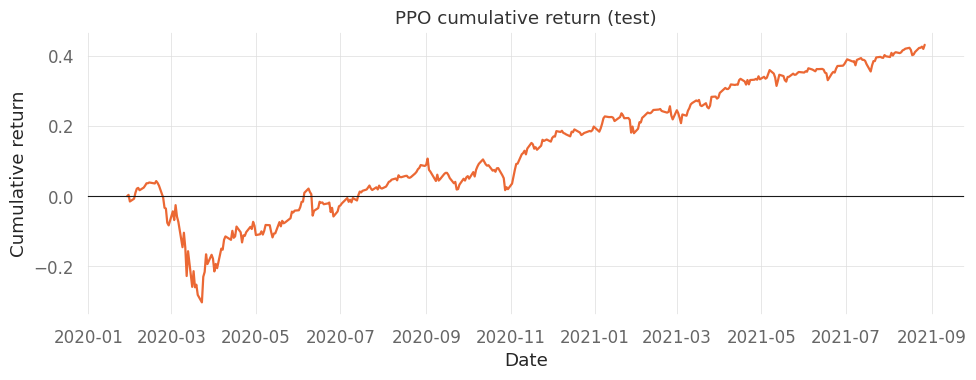

<Axes: title={'center': 'PPO cumulative return (test)'}, xlabel='Date', ylabel='Cumulative return'>

In [6]:
RLUtils.plot_curves(
    {"PPO": RLUtils.policy_curve(model_ppo, test, PPO_FEATURES)},
    "PPO cumulative return (test)",
)

In [7]:
if study_ppo is not None:
    ppo_trials = study_ppo.trials_dataframe()
    ppo_trials.columns = [c.replace("user_attrs_", "") for c in ppo_trials.columns]
    display(ppo_trials.sort_values("value", ascending=False))
    RLUtils.plot_training_curves("ppo", RLUtils.PPO_CURVES)


## DDPG

Same subset-then-retrain search. Trial logs go under `logs/ddpg`.


In [8]:
DDPG_FEATURES = FEATURE_LIST if TRAIN_DDPG else SAVED_FEATURE_LIST
if TRAIN_DDPG:
    model_ddpg, study_ddpg = RLUtils.tune_ddpg(train, DDPG_FEATURES)
else:
    model_ddpg = DDPG.load("ddpg_portfolio", device="cpu")
    study_ddpg = None

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 13819.19921875
Final accumulative portfolio value: 1.3819199800491333
Maximum DrawDown: -0.324108721291535
Sharpe ratio: 0.8521084376319129
Mean ex-ante daily vol: 0.013665326973994911
Mean deviation from equal weight: 0.21628163327888755


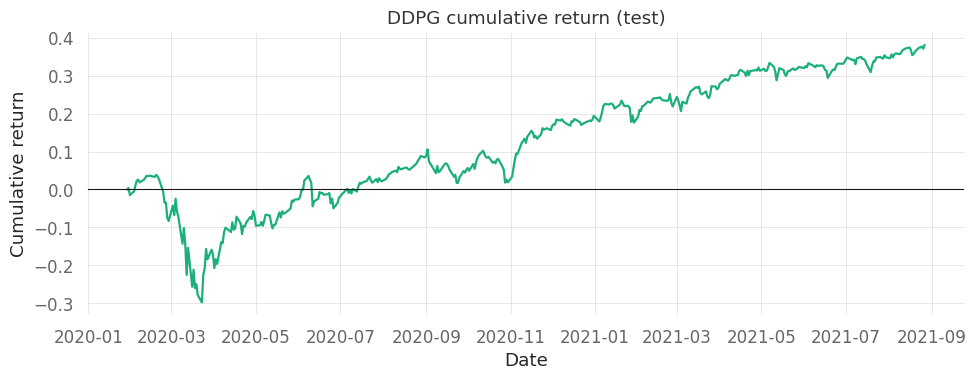

<Axes: title={'center': 'DDPG cumulative return (test)'}, xlabel='Date', ylabel='Cumulative return'>

In [9]:
RLUtils.plot_curves(
    {"DDPG": RLUtils.policy_curve(model_ddpg, test, DDPG_FEATURES)},
    "DDPG cumulative return (test)",
)

In [10]:
if study_ddpg is not None:
    ddpg_trials = study_ddpg.trials_dataframe()
    ddpg_trials.columns = [c.replace("user_attrs_", "") for c in ddpg_trials.columns]
    display(ddpg_trials.sort_values("value", ascending=False))
    RLUtils.plot_training_curves("ddpg", RLUtils.DDPG_CURVES)


## Strategy comparison


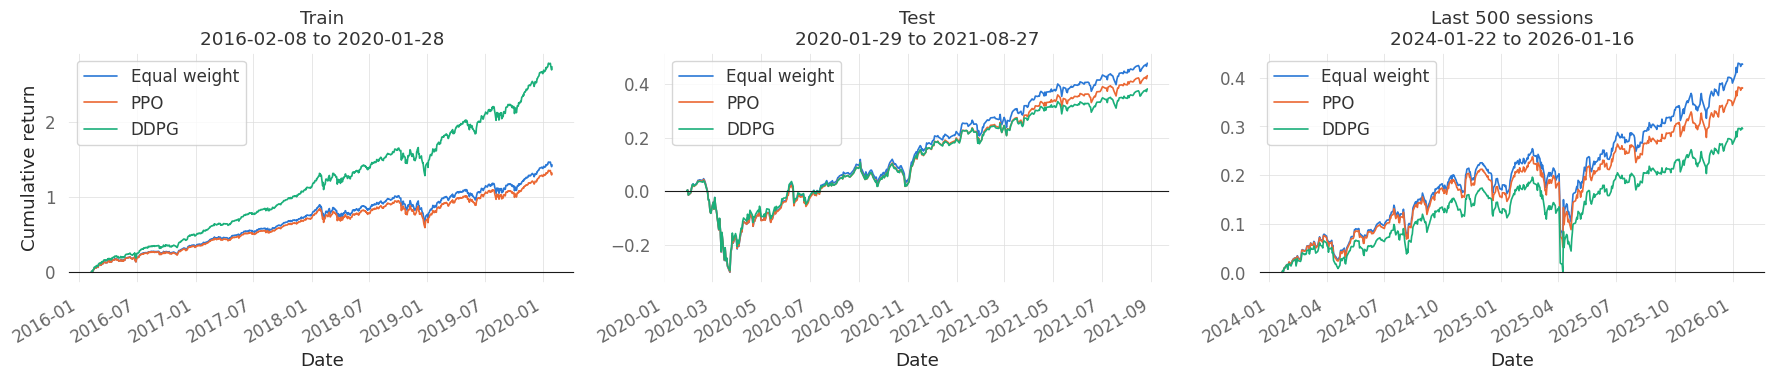

final value  total return  Sharpe  \
window            strategy                                          
Train             Equal weight   24284.3164        1.4284  1.7901   
                  PPO            23166.5234        1.3167  1.7110   
                  DDPG           37383.3594        2.7383  2.6398   
Test              Equal weight   14778.7773        0.4779  0.9959   
                  PPO            14314.0273        0.4314  0.9347   
                  DDPG           13819.1992        0.3819  0.8532   
Last 500 sessions Equal weight   14274.3252        0.4274  1.4038   
                  PPO            13786.7676        0.3787  1.2920   
                  DDPG           12949.9219        0.2950  1.0269   

                                max drawdown  daily turnover  \
window            strategy                                     
Train             Equal weight       -0.1831          0.0042   
                  PPO                -0.1849          0.0387   
                  DDPG               -0.1412          0.1391   
Test              Equal weight       -0.3345          0.0062   
                  PPO                -0.3314          0.0408   
                  DDPG               -0.3241          0.1347   
Last 500 sessions Equal weight       -0.1509          0.0053   
                  PPO                -0.1499          0.0394   
                  DDPG               -0.1630          0.1317   

                                gap to equal weight  
window            strategy                           
Train             Equal weight               0.0000  
                  PPO                        0.0627  
                  DDPG                       0.2234  
Test              Equal weight               0.0000  
                  PPO                        0.0624  
                  DDPG                       0.2163  
Last 500 sessions Equal weight               0.0000  
                  PPO                        0.0618  
                  DDPG                       0.2154

In [11]:
windows = {"Train": train, "Test": test, "Last 500 sessions": recent}
metrics = RLUtils.compare_strategies(
    windows,
    {"Equal weight": None, "PPO": model_ppo, "DDPG": model_ddpg},
    {"Equal weight": FEATURE_LIST, "PPO": PPO_FEATURES, "DDPG": DDPG_FEATURES},
)
metrics.round(4)

## RL on the dedicated feature file (share-trading env)

`data/rl_features.csv` holds exactly what this section reads: `date`, `tic`, the raw OHLCV, `day` (day of week, Monday = 0), the 11 scaled features, `rf_return` and `excess_ret`. `RLUtils.build_rl_panel` builds it from `data/features_panel.csv` and the raw prices in `data/created_df.csv`.

- `rf_return`: the daily return of the 3-month T-bill (FRED `DTB3`, cached in `data/risk_free.csv`), $(1 + r_{annual})^{1/252} - 1$. Bond-market holidays carry the previous rate forward. It depends only on the date, so every asset has the same value on a given day.
- `excess_ret`: each asset's close-to-close return minus the previous session's `rf_return`, the rate in force over that day.

The agent observes `RLUtils.RL_FEATURE_LIST`: raw OHLCV, `day`, the 11 scaled features, `rf_return` and `excess_ret`. `VecNormalize` z-scores every (feature, asset) input with running statistics from the training window only, clipped at ±10, and the same statistics are applied, unchanged, at test time. It trades whole shares in `ShareTradingEnv` (`trading_env.py`, FinRL's StockTradingEnv trading rules): $1,000,000 of starting cash, at most 100 shares per asset per step, 10 bp per trade. The step reward is the portfolio's log return minus $\log(1 + r_f)$ for that holding day, so the agent is scored on excess return over the T-bill. The models are built and trained with FinRL's `DRLAgent`, ported to `models.py`, with FinRL's default hyperparameters. A2C uses the same stack. The ensemble retrains A2C, PPO and DDPG on expanding windows and trades with the highest-Sharpe model.

The cells above are unchanged. Everything below uses its own variable names, so rerunning it leaves their results alone.

train: 2016-02-08 to 2020-01-28, 1000 sessions
test: 2020-01-29 to 2021-08-27, 400 sessions
last 500: 2024-01-22 to 2026-01-16, 500 sessions
most rf_return values on one date: 1


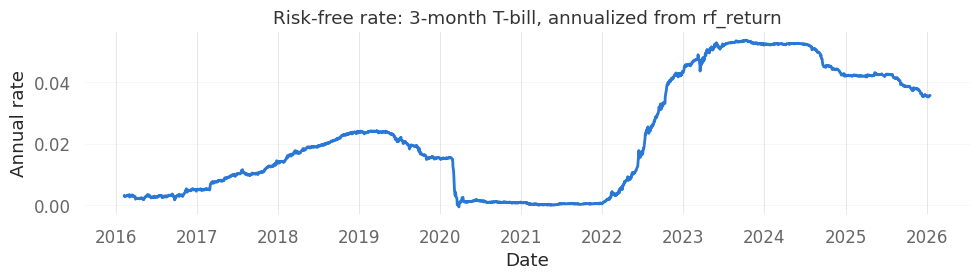

In [12]:
import contextlib
import io
from pathlib import Path

from models import DRLAgent, DRLEnsembleAgent, MODEL_KWARGS, config
from RLUtils import SERIES_COLORS

# True rebuilds data/rl_features.csv from features_panel.csv, created_df.csv and the rf cache.
REBUILD_RL_PANEL = False
if REBUILD_RL_PANEL or not Path(RLUtils.RL_PANEL_PATH).exists():
    RLUtils.build_rl_panel()

rl_data = pd.read_csv(RLUtils.RL_PANEL_PATH, parse_dates=["date"])
RL_FEATURES = RLUtils.RL_FEATURE_LIST
rl_train, rl_test = Utils.train_test_split(rl_data, TRAIN_WINDOW, TEST_WINDOW)
rl_train = rl_train.reset_index(drop=True)
rl_test = rl_test.reset_index(drop=True)
rl_recent = RLUtils.last_n_sessions(rl_data, 500)
for name, df in {"train": rl_train, "test": rl_test, "last 500": rl_recent}.items():
    print(f"{name}: {df['date'].min():%Y-%m-%d} to {df['date'].max():%Y-%m-%d}, {df['date'].nunique()} sessions")

# rf_return has one value per date, shared by every asset
print("most rf_return values on one date:", rl_data.groupby("date")["rf_return"].nunique().max())
rf = rl_data.drop_duplicates("date").set_index("date")["rf_return"]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(rf.index, (1 + rf) ** 252 - 1, color=SERIES_COLORS[0], lw=2)
ax.set_title("Risk-free rate: 3-month T-bill, annualized from rf_return")
ax.set_xlabel("Date")
ax.set_ylabel("Annual rate")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Check one observation before training: 19 features × 100 assets × 1 day, plus the current portfolio weights. OHLCV and `volume` enter unscaled, so their columns are orders of magnitude larger than the scaled features. `rf_return` is the same on every asset; `excess_ret` is not.

In [13]:
rl_env = RLUtils.make_share_env(rl_train, RL_FEATURES)
rl_obs, _ = rl_env.reset()
print(rl_env.observation_space)
print("state", rl_obs["state"].shape, "nan", np.isnan(rl_obs["state"]).sum(), "inf", np.isinf(rl_obs["state"]).sum())
pd.DataFrame(rl_obs["state"][:, :, -1], index=RL_FEATURES, columns=rl_env._tic_list).T.describe().T

Dict('state': Box(-inf, inf, (19, 100, 1), float32), 'weights': Box(0.0, 1.0, (101,), float32))
state (19, 100, 1) nan 0 inf 0


,count,mean,std,min,25%,50%,75%,max
open,100.0,6.692463e+01,7.381929e+01,0.831509,2.645373e+01,4.690145e+01,9.207889e+01,6.439753e+02
high,100.0,6.768585e+01,7.426566e+01,0.835662,2.698654e+01,4.729251e+01,9.375288e+01,6.462436e+02
low,100.0,6.506480e+01,7.094084e+01,0.793815,2.599059e+01,4.596964e+01,8.673607e+01,6.170528e+02
close,100.0,6.647256e+01,7.242996e+01,0.805635,2.676056e+01,4.684629e+01,9.070635e+01,6.293120e+02
volume,100.0,2.893679e+07,6.374173e+07,840578.000000,4.357412e+06,9.814444e+06,1.973192e+07,4.663682e+08
day,100.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
boll_pctb,100.0,2.984109e-01,3.193441e-01,-0.133875,1.859861e-02,2.101780e-01,5.988523e-01,9.550833e-01
volume_stad,100.0,6.349051e-01,8.575122e-01,-0.942026,1.036984e-02,5.536053e-01,1.220199e+00,2.494916e+00
rsi_6_scale,100.0,3.971192e-01,2.193005e-01,0.090091,2.129517e-01,3.376426e-01,5.779594e-01,9.463656e-01
macd_stad,100.0,-9.054070e-01,1.450856e+00,-2.755324,-2.135118e+00,-1.484011e+00,1.920532e-01,2.076186e+00


### PPO, DDPG and A2C with FinRL's `DRLAgent`

FinRL's train-once setup: `get_model` builds the model with the defaults in `models.config` (PPO: `n_steps=2048, lr=2.5e-4, batch=64, ent_coef=0.01`; DDPG: `batch=128, buffer=50k, lr=1e-3`, Normal action noise σ = 0.1; A2C: `n_steps=5, lr=7e-4, ent_coef=0.01`), and `train_model` runs `RLUtils.TOTAL_TIMESTEPS` steps on the training window. All three see the 19-column observation, including `rf_return` and `excess_ret`, and the excess-over-T-bill reward. Rewards are normalized as in the tuned runs above. Observations are normalized as described at the top of this section (`RLUtils.make_share_vec_env(..., norm_obs=True)`), and the statistics are saved next to each model as `<name>_rl_features_vecnormalize.pkl`. On 100 assets PPO runs 20k steps in about 20 s and DDPG in about 2 min. The models are saved to `trained_models/`, so the root `ppo_portfolio.zip` and `ddpg_portfolio.zip` are not overwritten.

In [14]:
# True trains PPO, DDPG and A2C below. False loads them, and their observation statistics, from trained_models/.
TRAIN_RL = True
RL_GAMMA = 0.99  # SB3's default discount, also used by the reward normalization

if TRAIN_RL:
    # norm_obs=True z-scores every (feature, asset) input with statistics from the training window only
    agent = DRLAgent(env=RLUtils.make_share_vec_env(rl_train, RL_FEATURES, RL_GAMMA, norm_obs=True, ew_penalty=RLUtils.EW_PENALTY))
    ppo_rl = agent.get_model("ppo", seed=42, verbose=0, tensorboard_log=config.TENSORBOARD_LOG_DIR)
    ppo_rl = DRLAgent.train_model(ppo_rl, tb_log_name="ppo_rl_features", total_timesteps=RLUtils.TOTAL_TIMESTEPS)
    ppo_rl.save(f"{config.TRAINED_MODEL_DIR}/ppo_rl_features")
    ppo_norm = ppo_rl.get_vec_normalize_env()
    ppo_norm.save(f"{config.TRAINED_MODEL_DIR}/ppo_rl_features_vecnormalize.pkl")
else:
    ppo_rl = PPO.load(f"{config.TRAINED_MODEL_DIR}/ppo_rl_features", device="cpu")
    ppo_norm = RLUtils.load_share_normalizer(f"{config.TRAINED_MODEL_DIR}/ppo_rl_features_vecnormalize.pkl", rl_train, RL_FEATURES)

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64, 'device': 'cpu'}


In [15]:
if TRAIN_RL:
    agent = DRLAgent(env=RLUtils.make_share_vec_env(rl_train, RL_FEATURES, RL_GAMMA, norm_obs=True, ew_penalty=RLUtils.EW_PENALTY))
    ddpg_rl = agent.get_model("ddpg", seed=42, verbose=0, tensorboard_log=config.TENSORBOARD_LOG_DIR)
    ddpg_rl = DRLAgent.train_model(ddpg_rl, tb_log_name="ddpg_rl_features", total_timesteps=RLUtils.TOTAL_TIMESTEPS)
    ddpg_rl.save(f"{config.TRAINED_MODEL_DIR}/ddpg_rl_features")
    ddpg_norm = ddpg_rl.get_vec_normalize_env()
    ddpg_norm.save(f"{config.TRAINED_MODEL_DIR}/ddpg_rl_features_vecnormalize.pkl")
else:
    ddpg_rl = DDPG.load(f"{config.TRAINED_MODEL_DIR}/ddpg_rl_features")
    ddpg_norm = RLUtils.load_share_normalizer(f"{config.TRAINED_MODEL_DIR}/ddpg_rl_features_vecnormalize.pkl", rl_train, RL_FEATURES)

{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.001, 'action_noise': NormalActionNoise(mu=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.], sigma=[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1])}


In [16]:
if TRAIN_RL:
    agent = DRLAgent(env=RLUtils.make_share_vec_env(rl_train, RL_FEATURES, RL_GAMMA, norm_obs=True, ew_penalty=RLUtils.EW_PENALTY))
    a2c_rl = agent.get_model("a2c", seed=42, verbose=0, tensorboard_log=config.TENSORBOARD_LOG_DIR)
    a2c_rl = DRLAgent.train_model(a2c_rl, tb_log_name="a2c_rl_features", total_timesteps=RLUtils.TOTAL_TIMESTEPS)
    a2c_rl.save(f"{config.TRAINED_MODEL_DIR}/a2c_rl_features")
    a2c_norm = a2c_rl.get_vec_normalize_env()
    a2c_norm.save(f"{config.TRAINED_MODEL_DIR}/a2c_rl_features_vecnormalize.pkl")
else:
    a2c_rl = A2C.load(f"{config.TRAINED_MODEL_DIR}/a2c_rl_features", device="cpu")
    a2c_norm = RLUtils.load_share_normalizer(f"{config.TRAINED_MODEL_DIR}/a2c_rl_features_vecnormalize.pkl", rl_train, RL_FEATURES)

{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007, 'device': 'cpu'}


### Ensemble of A2C, PPO and DDPG

Walk-forward on the test window. Every 63 sessions the three models are trained from scratch on the expanding history, scored by Sharpe on the next 63 sessions, and the winner trades the 63 sessions after that. SAC and TD3 are skipped. Each trading window starts from cash, so the test curve is the compounded daily returns of those windows, not a single account path.

In [17]:
TRAIN_ENSEMBLE = True
REBALANCE_WINDOW = 63
VALIDATION_WINDOW = 63


def stitch_ensemble_curve(results_dir, start_cash):
    """Compound daily returns across walk-forward trading windows that each start from cash."""
    paths = sorted(Path(results_dir).glob("account_value_trade_ensemble_*.csv"))
    if not paths:
        return None
    dates, values, turnovers = [], [start_cash], []
    for i, path in enumerate(paths):
        frame = pd.read_csv(path, parse_dates=["date"]).sort_values("date")
        if i == 0:
            dates.append(frame["date"].iloc[0])
        rets = frame["account_value"].pct_change().iloc[1:]
        for date, ret, turn in zip(frame["date"].iloc[1:], rets, frame["turnover"].iloc[1:]):
            dates.append(date)
            values.append(values[-1] * (1.0 + float(ret)))
            turnovers.append(float(turn) if pd.notna(turn) else np.nan)
    return pd.DataFrame({"date": dates, "account_value": values, "turnover": [np.nan] + turnovers})


if TRAIN_ENSEMBLE:
    results = Path(config.RESULTS_DIR)
    if results.exists():
        for path in results.glob("account_value_trade_ensemble_*.csv"):
            path.unlink()
    ensemble_agent = DRLEnsembleAgent(
        df=rl_data,
        features=RL_FEATURES,
        train_period=(rl_train["date"].min(), rl_test["date"].min()),
        val_test_period=(rl_train["date"].max(), rl_test["date"].max()),
        rebalance_window=REBALANCE_WINDOW,
        validation_window=VALIDATION_WINDOW,
        env_kwargs={"ew_penalty": RLUtils.EW_PENALTY},
        gamma=RL_GAMMA,
        norm_obs=True,
    )
    ensemble_summary = ensemble_agent.run_ensemble_strategy(
        A2C_model_kwargs=MODEL_KWARGS["a2c"],
        PPO_model_kwargs=MODEL_KWARGS["ppo"],
        DDPG_model_kwargs=MODEL_KWARGS["ddpg"],
        SAC_model_kwargs=None,
        TD3_model_kwargs=None,
        timesteps_dict={
            "a2c": RLUtils.TOTAL_TIMESTEPS,
            "ppo": RLUtils.TOTAL_TIMESTEPS,
            "ddpg": RLUtils.TOTAL_TIMESTEPS,
        },
    )
    display(ensemble_summary)

ensemble_account = stitch_ensemble_curve(config.RESULTS_DIR, RLUtils.SHARE_ENV_KWARGS["initial_amount"])
if ensemble_account is None:
    print("No ensemble account files under", config.RESULTS_DIR)
else:
    print("ensemble sessions:", len(ensemble_account), ensemble_account["date"].min().date(), "to", ensemble_account["date"].max().date())

============Start Ensemble Strategy============
======Model training from:  2016-02-08 00:00:00 to  2020-01-29 00:00:00
======a2c Training========
{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007, 'device': 'cpu'}
Using cpu device
Logging to tensorboard_log/a2c/a2c_126_1
----------------------------------------
| time/                 |              |
|    fps                | 812          |
|    iterations         | 100          |
|    time_elapsed       | 0            |
|    total_timesteps    | 500          |
| train/                |              |
|    entropy_loss       | -142         |
|    explained_variance | -0.0276      |
|    learning_rate      | 0.0007       |
|    n_updates          | 99           |
|    policy_loss        | 24.1         |
|    reward             | -0.057226926 |
|    reward_max         | 1.0547264    |
|    reward_mean        | -0.008477819 |
|    reward_min         | -0.52598006  |
|    std                | 1            |
|    value_loss        

,Iter,Val Start,Val End,Model Used,A2C Sharpe,PPO Sharpe,DDPG Sharpe,SAC Sharpe,TD3 Sharpe
0,126,2020-01-29 00:00:00,2020-04-29 00:00:00,A2C,-0.054823,-0.438735,-0.388397,NaN,NaN
1,189,2020-04-29 00:00:00,2020-07-29 00:00:00,PPO,2.628622,2.82324,2.585198,NaN,NaN
2,252,2020-07-29 00:00:00,2020-10-27 00:00:00,PPO,0.764133,1.708789,0.906823,NaN,NaN
3,315,2020-10-27 00:00:00,2021-01-28 00:00:00,A2C,2.893255,1.503925,1.653016,NaN,NaN
4,378,2021-01-28 00:00:00,2021-04-29 00:00:00,DDPG,2.91334,3.232911,3.697786,NaN,NaN


ensemble sessions: 311 2020-04-29 to 2021-07-28


### Action check

Does each policy react to the market, and are its inputs inside the range it was trained on?

- **actions at ±1**: share of daily actions at the ends of the action range (buy or sell 100 shares).
- **distinct daily actions**: number of different action vectors over the window. A policy that ignores its inputs repeats one vector.
- **OHLCV inputs clipped**: share of normalized OHLCV inputs at the ±10 clip, i.e. far outside the training window's range.

Before observations were normalized, DDPG's actions were all at ±1 with only 3 distinct vectors over the 199 test steps: raw volume (up to about 5e8) set them, and zeroing the 11 scaled features changed nothing. With normalization DDPG reacts to the features, but its actions are still almost all at ±1, since a deterministic DDPG actor tends to push to the bounds. Price levels also trend over the decade: in the last 500 sessions OHLC sit a median of about 6.8 training standard deviations above the training mean and about 29% of them hit the clip, so the policies see inputs far outside what they trained on.

In [18]:
raw_idx = [RL_FEATURES.index(c) for c in RLUtils.RAW_COLUMNS]
rl_action_rows = {}
for window, df in {"Test": rl_test, "Last 500 sessions": rl_recent}.items():
    for name, (model, norm) in {"PPO": (ppo_rl, ppo_norm), "DDPG": (ddpg_rl, ddpg_norm), "A2C": (a2c_rl, a2c_norm)}.items():
        env = RLUtils.make_share_env(df, RL_FEATURES)
        obs, _ = env.reset()
        actions = []
        while env._time_index < len(env._sorted_times) - 1:
            action, _ = model.predict(norm.normalize_obs(obs), deterministic=True)
            actions.append(action)
            obs, *_ = env.step(action)
        actions = np.asarray(actions)
        rms = norm.obs_rms["state"]
        z = (env._state_array - rms.mean[..., 0]) / np.sqrt(rms.var[..., 0] + norm.epsilon)
        rl_action_rows[(window, name)] = {
            "actions at ±1": np.mean(np.abs(actions) >= 0.99),
            "distinct daily actions": len(np.unique(actions.round(4), axis=0)),
            "steps": len(actions),
            "OHLCV inputs clipped": np.mean(np.abs(z[:, raw_idx]) >= norm.clip_obs),
        }
pd.DataFrame(rl_action_rows).T.round(3)

actions at ±1  distinct daily actions  steps  \
Test              PPO           0.000                   399.0  399.0   
                  DDPG          1.000                   137.0  399.0   
                  A2C           0.411                   393.0  399.0   
Last 500 sessions PPO           0.000                   499.0  499.0   
                  DDPG          1.000                    31.0  499.0   
                  A2C           0.443                   428.0  499.0   

                        OHLCV inputs clipped  
Test              PPO                  0.012  
                  DDPG                 0.011  
                  A2C                  0.011  
Last 500 sessions PPO                  0.232  
                  DDPG                 0.231  
                  A2C                  0.231

### Comparison with equal weight

Each window is one deterministic run from $1,000,000 in cash. The benchmark is the equal-weight portfolio from above (1/n in every asset, rebalanced every session, 10 bp costs). Test is the 400 sessions after training. The last 500 sessions are about the final two years of data. The ensemble is scored only on the walk-forward test windows.

- **Sharpe**: $\sqrt{252}$ × mean / std of daily portfolio returns (returns, not excess returns).
- **Max drawdown**: the worst fall from a running peak. **Avg drawdown**: the mean daily distance below the running peak.
- **Daily turnover**: traded value / portfolio value, averaged over sessions (not tracked for the benchmark).

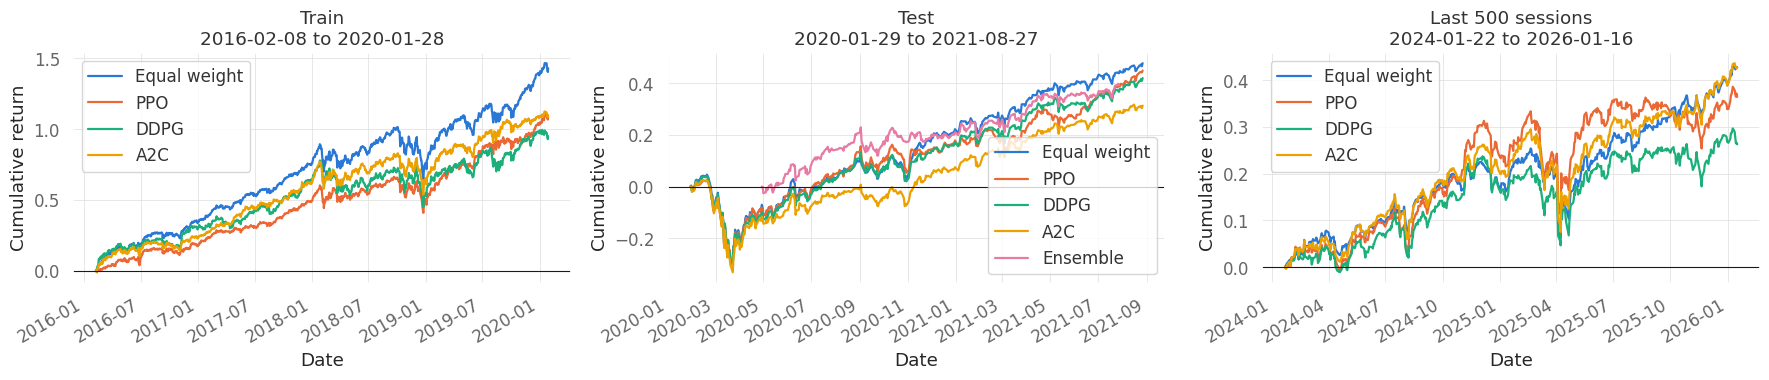

final value  total return  Sharpe  \
window            strategy                                           
Train             Equal weight  2.428432e+06        1.4284  1.7901   
                  PPO           2.085111e+06        1.0851  1.6394   
                  DDPG          1.949426e+06        0.9494  1.2261   
                  A2C           2.098247e+06        1.0982  1.5599   
Test              Equal weight  1.477878e+06        0.4779  0.9959   
                  PPO           1.449371e+06        0.4494  0.9519   
                  DDPG          1.420211e+06        0.4202  0.9014   
                  A2C           1.313316e+06        0.3133  0.7512   
Last 500 sessions Equal weight  1.427433e+06        0.4274  1.4038   
                  PPO           1.364589e+06        0.3646  1.1219   
                  DDPG          1.262900e+06        0.2629  0.8813   
                  A2C           1.426192e+06        0.4262  1.3089   
Test              Ensemble      1.392640e+06        0.3926  1.7414   

                                max drawdown  avg drawdown  daily turnover  
window            strategy                                                  
Train             Equal weight       -0.1831       -0.0177             NaN  
                  PPO                -0.1527       -0.0152          0.0244  
                  DDPG               -0.1839       -0.0323          0.0359  
                  A2C                -0.1593       -0.0177          0.0177  
Test              Equal weight       -0.3345       -0.0403             NaN  
                  PPO                -0.3154       -0.0405          0.0161  
                  DDPG               -0.3274       -0.0453          0.0086  
                  A2C                -0.3477       -0.0513          0.0104  
Last 500 sessions Equal weight       -0.1509       -0.0158             NaN  
                  PPO                -0.1651       -0.0246          0.0030  
                  DDPG               -0.1539       -0.0245          0.0021  
                  A2C                -0.1696       -0.0198          0.0020  
Test              Ensemble           -0.0892       -0.0160          0.0240

In [19]:
rl_windows = {"Train": rl_train, "Test": rl_test, "Last 500 sessions": rl_recent}
rl_curves, rl_rows = {}, {}
start_cash = RLUtils.SHARE_ENV_KWARGS["initial_amount"]
with contextlib.redirect_stdout(io.StringIO()):  # PortfolioOptimizationEnv prints every ticker when built
    for window, df in rl_windows.items():
        dates, ew_cumulative = RLUtils.equal_weight_curve(df, RL_FEATURES, save_plots=False)
        rl_curves[window] = {"Equal weight": (dates, ew_cumulative)}
        rl_rows[(window, "Equal weight")] = RLUtils.value_metrics(start_cash * (1 + ew_cumulative))
        for name, (model, norm) in {"PPO": (ppo_rl, ppo_norm), "DDPG": (ddpg_rl, ddpg_norm), "A2C": (a2c_rl, a2c_norm)}.items():
            account, _ = DRLAgent.DRL_prediction(model, RLUtils.make_share_env(df, RL_FEATURES), obs_normalizer=norm)
            values = account["account_value"].to_numpy()
            rl_curves[window][name] = (account["date"], values / values[0] - 1)
            rl_rows[(window, name)] = RLUtils.value_metrics(values, account["turnover"])
    if ensemble_account is not None:
        values = ensemble_account["account_value"].to_numpy()
        rl_curves["Test"]["Ensemble"] = (ensemble_account["date"], values / values[0] - 1)
        rl_rows[("Test", "Ensemble")] = RLUtils.value_metrics(values, ensemble_account["turnover"])

fig, axes = plt.subplots(1, len(rl_windows), figsize=(6 * len(rl_windows), 4), squeeze=False)
for ax, window in zip(axes.flat, rl_windows):
    span = rl_windows[window]["date"]
    RLUtils.plot_curves(rl_curves[window], f"{window}\n{span.min():%Y-%m-%d} to {span.max():%Y-%m-%d}", ax=ax)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

rl_metrics = pd.DataFrame(rl_rows).T
rl_metrics.index.names = ["window", "strategy"]
rl_metrics.round(4)